Step 2: ML

In [1]:
import joblib
import os
import pandas as pd
import numpy as np

data_dir = "../data"

X = joblib.load(os.path.join(data_dir, "dp_features_magpie_stoich_ion.pkl"))
y_gap = joblib.load(os.path.join(data_dir, "dp_bandgap_targets.pkl"))
y_hull = joblib.load(os.path.join(data_dir, "dp_ehull_targets.pkl"))
y_form = joblib.load(os.path.join(data_dir, "dp_formation_energy_targets.pkl"))

print("Feature matrix:", X.shape)
print("Band gap target:", y_gap.shape)
print("Ehull target:", y_hull.shape)
print("Formation energy target:", y_form.shape)
print("Remaining NaNs:", X.isna().sum().sum())

Feature matrix: (676, 140)
Band gap target: (676,)
Ehull target: (676,)
Formation energy target: (676,)
Remaining NaNs: 0


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_gap,
    test_size=0.2,
    random_state=42
)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 540
Test samples: 136


In [3]:
from sklearn.ensemble import RandomForestRegressor

rf_gap = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_gap.fit(X_train, y_train)

print("Random Forest band gap model trained.")

Random Forest band gap model trained.


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

y_pred = rf_gap.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Band gap MAE:  {mae:.3f} eV")
print(f"Band gap RMSE: {rmse:.3f} eV")
print(f"Band gap R²:   {r2:.3f}")

Band gap MAE:  0.358 eV
Band gap RMSE: 0.521 eV
Band gap R²:   0.770


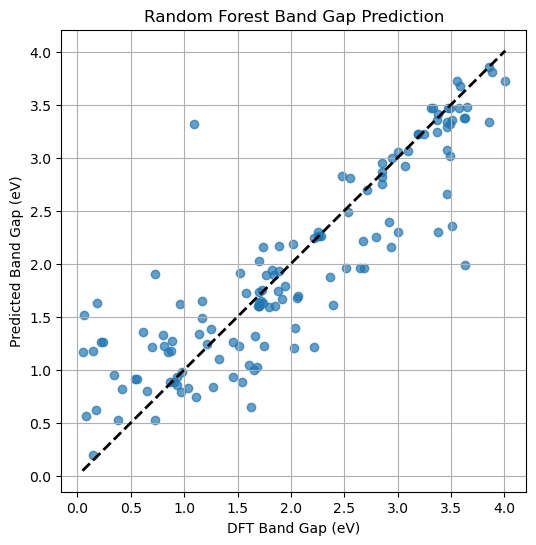

In [5]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "k--", lw=2)
plt.xlabel("DFT Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.title("Random Forest Band Gap Prediction")
plt.grid(True)
plt.show()

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf_hull = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_form = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_hull.fit(X, y_hull)
rf_form.fit(X, y_form)

print("Ehull and formation energy models trained.")

Ehull and formation energy models trained.


In [7]:
# Feature importance

# Feature importance analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_gap.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

# Print top 20 features
print("Top 20 important features:")
display(importance_df.head(20))

Top 20 important features:


,feature,importance
0,MagpieData avg_dev Electronegativity,0.102811
1,MagpieData mean Column,0.075884
2,MagpieData avg_dev NValence,0.054419
3,MagpieData avg_dev Column,0.039858
4,MagpieData mean SpaceGroupNumber,0.038034
5,MagpieData avg_dev NdValence,0.031218
6,MagpieData mean MendeleevNumber,0.030408
7,MagpieData mean Electronegativity,0.030176
8,MagpieData mean NUnfilled,0.028484
9,MagpieData mean MeltingT,0.027782


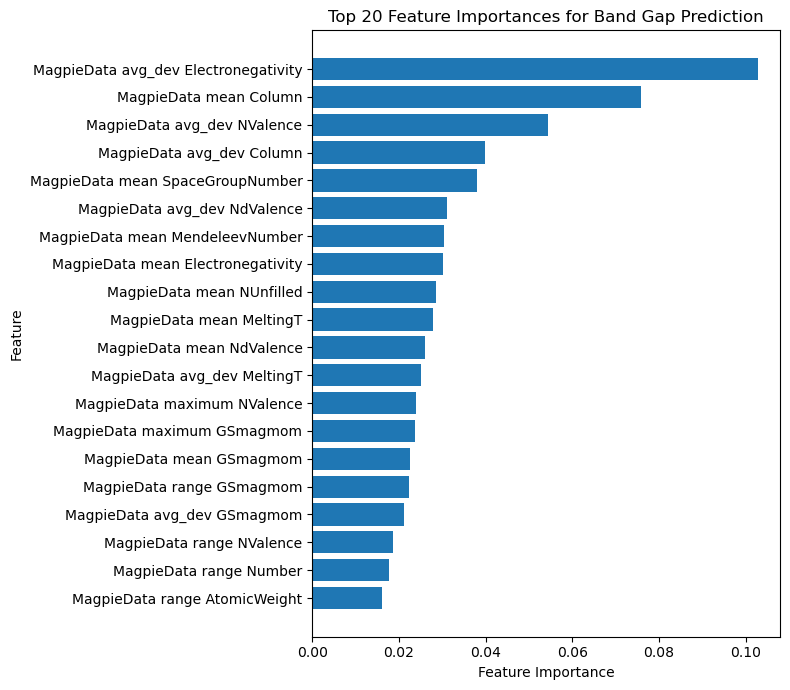

In [8]:
# Plot top 20 feature importances
top_n = 20
top_features = importance_df.head(top_n)

plt.figure(figsize=(8, 7))
plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances for Band Gap Prediction")
plt.tight_layout()
plt.show()

In [9]:
joblib.dump(rf_gap, "rf_bandgap_dp.pkl")
joblib.dump(rf_hull, "rf_ehull_dp.pkl")
joblib.dump(rf_form, "rf_formation_energy_dp.pkl")

print("Models saved for GA inverse design.")

Models saved for GA inverse design.
